# TFG Matemáticas y Física — Capítulo 5  
## Resultados y análisis experimental

Este notebook está pensado como **guion computacional detallado** para redactar el Capítulo 5 del TFG *Redes neuronales energéticas: redes neuronales como sistemas físicos*.

El notebook genera:

- tablas de métricas,
- curvas de recuperación frente al ruido,
- curvas de capacidad,
- evolución de la energía,
- detección de estados espurios,
- reconstrucciones de imágenes,
- visualización de filtros de la RBM,
- comparación train/test,
- resúmenes exportables a `.csv`.


## 1. Librerías, configuración y reproducibilidad

In [1]:
import itertools
import time
from pathlib import Path

import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import BernoulliRBM
from sklearn.metrics import mean_squared_error

# Carpeta para guardar tablas y figuras que luego se pueden incorporar a LaTeX.
RESULTS_DIR = Path("resultados_capitulo_5")
FIGURES_DIR = RESULTS_DIR / "figuras"
TABLES_DIR = RESULTS_DIR / "tablas"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Semilla global para reproducibilidad.
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

print("Carpeta de resultados:", RESULTS_DIR.resolve())
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Carpeta de resultados: /Users/noeliarosales/TFG mates/resultados_capitulo_5
NumPy: 2.1.3
scikit-learn: 1.6.1


## 2. Funciones auxiliares generales

In [2]:
def add_noise(pattern, noise_level=0.2, rng=None):
    """
    Invierte aleatoriamente un porcentaje de componentes de un patrón binario {-1, 1}.

    Parámetros
    ----------
    pattern : array-like
        Vector binario con valores -1 y 1.
    noise_level : float
        Proporción de bits que se invierten.
    rng : np.random.Generator o int
        Generador aleatorio o semilla.
    """
    rng = np.random.default_rng(rng)
    noisy = np.array(pattern, copy=True)
    n_flip = int(noise_level * noisy.size)

    if n_flip > 0:
        indices = rng.choice(noisy.size, size=n_flip, replace=False)
        noisy[indices] *= -1

    return noisy


def overlap(state, pattern):
    """Solapamiento entre dos patrones de Hopfield en {-1, 1}."""
    state = np.asarray(state)
    pattern = np.asarray(pattern)
    return np.mean(state * pattern)


def exact_match(state, patterns):
    """Devuelve True si state coincide exactamente con alguno de los patrones almacenados."""
    return any(np.array_equal(state, p) for p in patterns)


def best_overlap(state, patterns):
    """Mayor solapamiento de un estado final con los patrones almacenados."""
    return max(overlap(state, p) for p in patterns)


def plot_pattern(pattern, shape=(5, 5), title=None, ax=None):
    """Visualiza un patrón binario {-1, 1}."""
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(np.asarray(pattern).reshape(shape), cmap="gray", vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=18)
    return ax

def binary_cross_entropy(x, x_rec, eps=1e-10):
    """
    Entropía cruzada binaria media entre x y su reconstrucción.
    Se usa para datos normalizados en [0, 1].
    """
    x = np.asarray(x)
    x_rec = np.clip(np.asarray(x_rec), eps, 1 - eps)
    return -np.mean(x * np.log(x_rec) + (1 - x) * np.log(1 - x_rec))

## 3. Modelo de Hopfield utilizado en los experimentos

In [3]:
class HopfieldNetwork:
    """
    Red de Hopfield binaria con estados {-1, 1}.

    Incluye:
    - entrenamiento por regla de Hebb,
    - actualización asíncrona,
    - cálculo de energía,
    - historial de energía durante la recuperación.
    """

    def __init__(self):
        self.W = None
        self.n_units = None

    def fit(self, patterns):
        patterns = np.asarray(patterns)
        n_patterns, n_units = patterns.shape

        W = np.zeros((n_units, n_units))
        for p in patterns:
            W += np.outer(p, p)

        W /= n_units
        np.fill_diagonal(W, 0.0)

        self.W = W
        self.n_units = n_units
        return self

    def energy(self, state):
        state = np.asarray(state)
        return -0.5 * state @ self.W @ state

    def recall(self, initial_state, max_iter=50, rng=None, return_history=True):
        """
        Recupera un patrón mediante actualización asíncrona.

        En cada iteración se actualizan todas las neuronas en orden aleatorio.
        El proceso se detiene si una pasada completa no produce cambios.
        """
        rng = np.random.default_rng(rng)
        state = np.array(initial_state, copy=True)

        energy_history = [self.energy(state)]
        states_history = [state.copy()]

        for iteration in range(max_iter):
            previous = state.copy()
            order = rng.permutation(self.n_units)

            for i in order:
                h_i = self.W[i] @ state
                state[i] = 1 if h_i >= 0 else -1

            energy_history.append(self.energy(state))
            states_history.append(state.copy())

            if np.array_equal(state, previous):
                break

        if return_history:
            return state, np.array(energy_history), states_history

        return state

## 4. Patrones sintéticos base para Hopfield

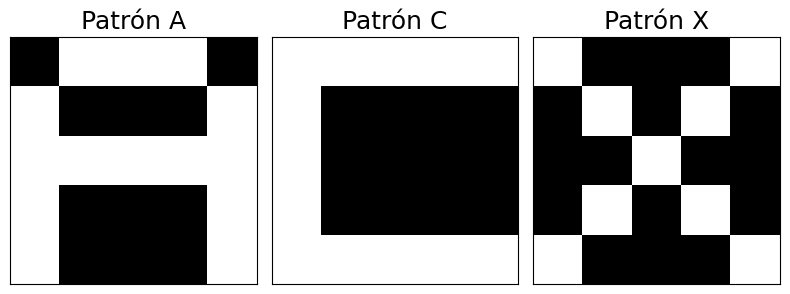

In [4]:
patterns_5x5 = np.array([
    # A
    [-1, 1, 1, 1,-1,
      1,-1,-1,-1, 1,
      1, 1, 1, 1, 1,
      1,-1,-1,-1, 1,
      1,-1,-1,-1, 1],

    # C
    [ 1, 1, 1, 1, 1,
      1,-1,-1,-1,-1,
      1,-1,-1,-1,-1,
      1,-1,-1,-1,-1,
      1, 1, 1, 1, 1],

    # X
    [ 1,-1,-1,-1, 1,
     -1, 1,-1, 1,-1,
     -1,-1, 1,-1,-1,
     -1, 1,-1, 1,-1,
      1,-1,-1,-1, 1]
])

fig, axes = plt.subplots(1, len(patterns_5x5), figsize=(8, 3))
for ax, p, name in zip(axes, patterns_5x5, ["A", "C", "X"]):
    plot_pattern(p, title=f"Patrón {name}",ax=ax)
    ax.set_title(f"Patrón {name}", fontsize=18)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "hopfield_patrones_base.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Experimento 1: recuperación de un patrón ruidoso y evolución de la energía

Coincide con el original: True
Solapamiento final con el original: 1.0
Energía inicial: -1.1199999999999999
Energía final: -12.799999999999999
Iteraciones: 2


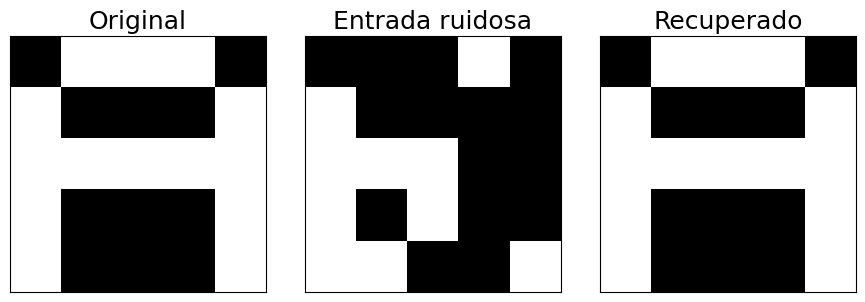

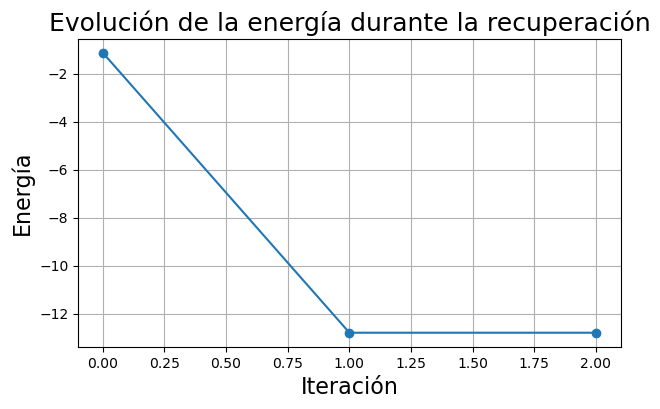

In [5]:
net = HopfieldNetwork().fit(patterns_5x5)

original = patterns_5x5[0]
noisy = add_noise(original, noise_level=0.32, rng=SEED)
recovered, energies, states = net.recall(noisy, max_iter=30, rng=SEED)

print("Coincide con el original:", np.array_equal(recovered, original))
print("Solapamiento final con el original:", overlap(recovered, original))
print("Energía inicial:", energies[0])
print("Energía final:", energies[-1])
print("Iteraciones:", len(energies) - 1)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
plot_pattern(original, title="Original", ax=axes[0])
plot_pattern(noisy, title="Entrada ruidosa", ax=axes[1])
plot_pattern(recovered, title="Recuperado", ax=axes[2])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hopfield_recuperacion_ejemplo.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(range(len(energies)), energies, marker="o")
plt.xlabel("Iteración",fontsize=16)
plt.ylabel("Energía",fontsize=16)
plt.title("Evolución de la energía durante la recuperación",fontsize=18)
plt.savefig(FIGURES_DIR / "hopfield_energia_ejemplo.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Experimento 2: efecto del ruido en la recuperación de Hopfield

In [6]:
def evaluate_hopfield_noise(patterns, noise_levels, trials=100, max_iter=50, seed=SEED):
    rng = np.random.default_rng(seed)
    net = HopfieldNetwork().fit(patterns)
    rows = []

    for noise in noise_levels: #se parte de un nivel de ruido determinado
        exact_count = 0
        overlaps = []
        final_energies = []
        iterations = []
        spurious_count = 0

        for _ in range(trials):
            idx = rng.integers(len(patterns)) #elige un patrón aleatorio que se va a estudiar
            original = patterns[idx] 
            noisy = add_noise(original, noise_level=noise, rng=rng)
            recovered, energies, _ = net.recall(noisy, max_iter=max_iter, rng=rng)

            is_exact = np.array_equal(recovered, original)
            exact_count += int(is_exact)
            overlaps.append(overlap(recovered, original))
            final_energies.append(energies[-1])
            iterations.append(len(energies) - 1)

            # Estado espurio: no coincide con ningún patrón almacenado.
            if not exact_match(recovered, patterns):
                spurious_count += 1

        rows.append({
            "noise_level": noise,
            "recovery_rate": exact_count / trials,
            "mean_overlap": np.mean(overlaps),
            "std_overlap": np.std(overlaps),
            "mean_final_energy": np.mean(final_energies),
            "mean_iterations": np.mean(iterations),
            "spurious_rate": spurious_count / trials
        })

    return pd.DataFrame(rows)


noise_levels = np.linspace(0, 0.60, 13)
df_hop_noise = evaluate_hopfield_noise(
    patterns_5x5,
    noise_levels=noise_levels,
    trials=200,
    max_iter=40,
    seed=SEED
)

df_hop_noise.to_csv(TABLES_DIR / "hopfield_ruido.csv", index=False)
df_hop_noise

,noise_level,recovery_rate,mean_overlap,std_overlap,mean_final_energy,mean_iterations,spurious_rate
0,0.00,1.000,1.0000,0.000000,-12.3248,1.000,0.000
1,0.05,1.000,1.0000,0.000000,-12.2384,2.000,0.000
2,0.10,0.995,0.9984,0.022571,-12.3232,2.000,0.005
3,0.15,0.965,0.9856,0.080303,-12.3672,2.005,0.035
4,0.20,0.905,0.9620,0.125204,-12.2360,2.040,0.095
5,0.25,0.875,0.9416,0.163895,-12.3056,2.060,0.120
6,0.30,0.790,0.8988,0.224781,-12.1632,2.070,0.190
7,0.35,0.620,0.7836,0.322966,-12.3352,2.145,0.325
8,0.40,0.345,0.5004,0.451451,-12.3424,2.180,0.480
9,0.45,0.185,0.2692,0.447977,-12.3368,2.215,0.485


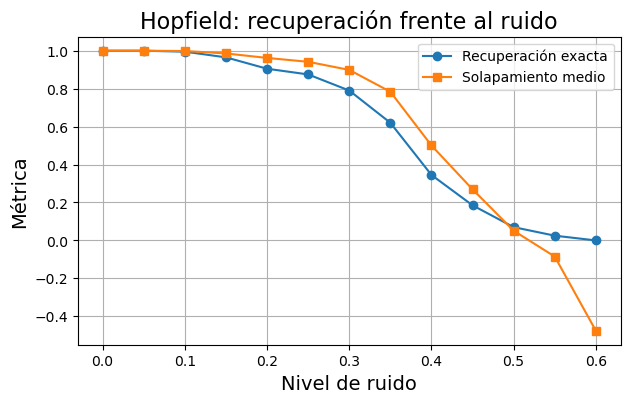

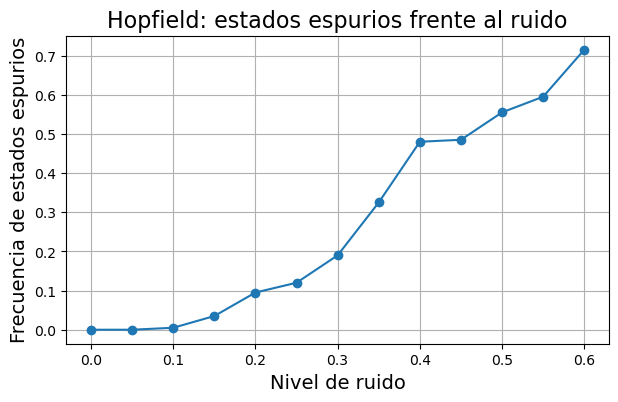

In [7]:
plt.figure()
plt.plot(df_hop_noise["noise_level"], df_hop_noise["recovery_rate"], marker="o", label="Recuperación exacta")
plt.plot(df_hop_noise["noise_level"], df_hop_noise["mean_overlap"], marker="s", label="Solapamiento medio")
plt.xlabel("Nivel de ruido",fontsize=14)
plt.ylabel("Métrica",fontsize=14)
plt.title("Hopfield: recuperación frente al ruido",fontsize=16)
plt.legend()
plt.savefig(FIGURES_DIR / "hopfield_ruido_recuperacion.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_hop_noise["noise_level"], df_hop_noise["spurious_rate"], marker="o")
plt.xlabel("Nivel de ruido",fontsize=14)
plt.ylabel("Frecuencia de estados espurios",fontsize=14)
plt.title("Hopfield: estados espurios frente al ruido",fontsize=16)
plt.savefig(FIGURES_DIR / "hopfield_ruido_espurios.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Experimento 3: capacidad de almacenamiento e interferencia entre patrones

In [8]:
def random_patterns(n_patterns, n_units, rng=None):
    rng = np.random.default_rng(rng)
    return rng.choice([-1, 1], size=(n_patterns, n_units))


def evaluate_hopfield_capacity(
    n_units=100,
    pattern_counts=(2, 4, 6, 8, 10, 12, 14, 16, 18, 20),
    noise_level=0.15,
    trials=200,
    max_iter=60,
    seed=SEED
):
    rng = np.random.default_rng(seed)
    rows = []

    for p in pattern_counts:
        patterns = random_patterns(p, n_units, rng=rng)
        net = HopfieldNetwork().fit(patterns)

        exact_count = 0
        overlaps = []
        spurious_count = 0
        final_energies = []

        for _ in range(trials):
            idx = rng.integers(p)
            original = patterns[idx]
            noisy = add_noise(original, noise_level=noise_level, rng=rng)
            recovered, energies, _ = net.recall(noisy, max_iter=max_iter, rng=rng)

            exact_count += int(np.array_equal(recovered, original))
            overlaps.append(overlap(recovered, original))
            final_energies.append(energies[-1])

            if not exact_match(recovered, patterns):
                spurious_count += 1

        rows.append({
            "n_units": n_units,
            "n_patterns": p,
            "alpha": p / n_units,
            "theoretical_alpha": 0.138,
            "recovery_rate": exact_count / trials,
            "mean_overlap": np.mean(overlaps),
            "spurious_rate": spurious_count / trials,
            "mean_final_energy": np.mean(final_energies)
        })

    return pd.DataFrame(rows)


df_hop_capacity = evaluate_hopfield_capacity(
    n_units=100,
    pattern_counts=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 24, 28],
    noise_level=0.15,
    trials=200,
    seed=SEED
)

df_hop_capacity.to_csv(TABLES_DIR / "hopfield_capacidad.csv", index=False)
df_hop_capacity

,n_units,n_patterns,alpha,theoretical_alpha,recovery_rate,mean_overlap,spurious_rate,mean_final_energy
0,100,2,0.02,0.138,1.000,1.0000,0.000,-49.9800
1,100,4,0.04,0.138,1.000,1.0000,0.000,-49.6298
2,100,6,0.06,0.138,1.000,1.0000,0.000,-50.1092
3,100,8,0.08,0.138,1.000,1.0000,0.000,-48.8074
4,100,10,0.10,0.138,0.930,0.9865,0.070,-48.4080
5,100,12,0.12,0.138,0.615,0.9598,0.385,-50.8650
6,100,14,0.14,0.138,0.645,0.8836,0.355,-51.5004
7,100,16,0.16,0.138,0.525,0.8974,0.475,-51.0382
8,100,18,0.18,0.138,0.325,0.8436,0.675,-52.7460
9,100,20,0.20,0.138,0.155,0.7535,0.845,-50.8936


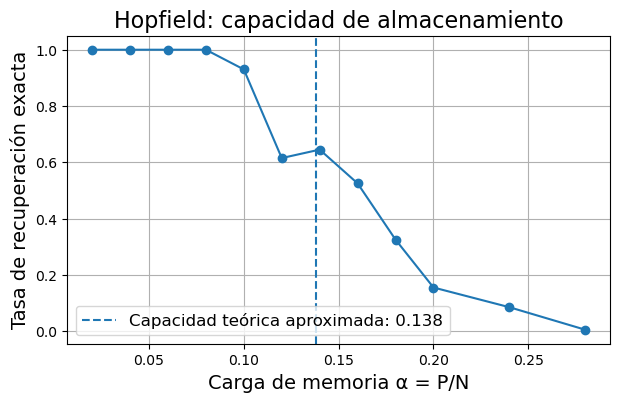

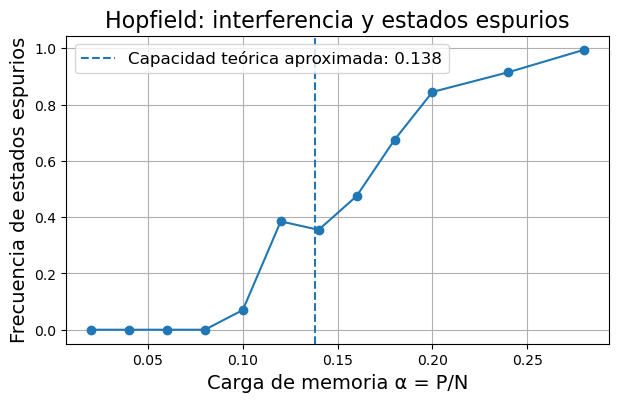

In [9]:
plt.figure()
plt.plot(df_hop_capacity["alpha"], df_hop_capacity["recovery_rate"], marker="o")
plt.axvline(0.138, linestyle="--", label="Capacidad teórica aproximada: 0.138")
plt.xlabel("Carga de memoria α = P/N",fontsize=14)
plt.ylabel("Tasa de recuperación exacta",fontsize=14)
plt.title("Hopfield: capacidad de almacenamiento",fontsize=16)
plt.legend(fontsize=12)
plt.savefig(FIGURES_DIR / "hopfield_capacidad.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_hop_capacity["alpha"], df_hop_capacity["spurious_rate"], marker="o")
plt.axvline(0.138, linestyle="--", label="Capacidad teórica aproximada: 0.138")
plt.xlabel("Carga de memoria α = P/N",fontsize=14)
plt.ylabel("Frecuencia de estados espurios",fontsize=14)
plt.title("Hopfield: interferencia y estados espurios",fontsize=16)
plt.legend(fontsize=12)
plt.savefig(FIGURES_DIR / "hopfield_capacidad_espurios.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Experimento 4: estados espurios y mínimos locales

In [10]:
def search_spurious_states(patterns, noise_level=0.35, trials=500, seed=SEED):
    rng = np.random.default_rng(seed)
    net = HopfieldNetwork().fit(patterns)
    counts = {}

    for _ in range(trials):
        idx = rng.integers(len(patterns))
        noisy = add_noise(patterns[idx], noise_level=noise_level, rng=rng)
        recovered, energies, _ = net.recall(noisy, max_iter=50, rng=rng)

        if not exact_match(recovered, patterns):
            key = tuple(recovered.tolist())
            if key not in counts:
                counts[key] = {
                    "state": recovered.copy(),
                    "count": 0,
                    "energy": net.energy(recovered),
                    "best_overlap": best_overlap(recovered, patterns)
                }
            counts[key]["count"] += 1

    if not counts:
        return pd.DataFrame(columns=["state", "count", "energy", "best_overlap"])

    df = pd.DataFrame(counts.values()).sort_values("count", ascending=False)
    return df.reset_index(drop=True)


df_spurious = search_spurious_states(patterns_5x5, noise_level=0.40, trials=1000, seed=SEED)
df_spurious.to_csv(TABLES_DIR / "hopfield_estados_espurios.csv", index=False)
df_spurious.head()

,state,count,energy,best_overlap
0,"[-1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1, 1, -1, ...",115,-12.48,0.68
1,"[1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1, -1, -1...",108,-12.80,0.36
2,"[-1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1...",83,-12.80,0.36
3,"[-1, -1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1, 1,...",70,-11.36,0.12
4,"[1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1, -1, 1,...",61,-12.48,0.68


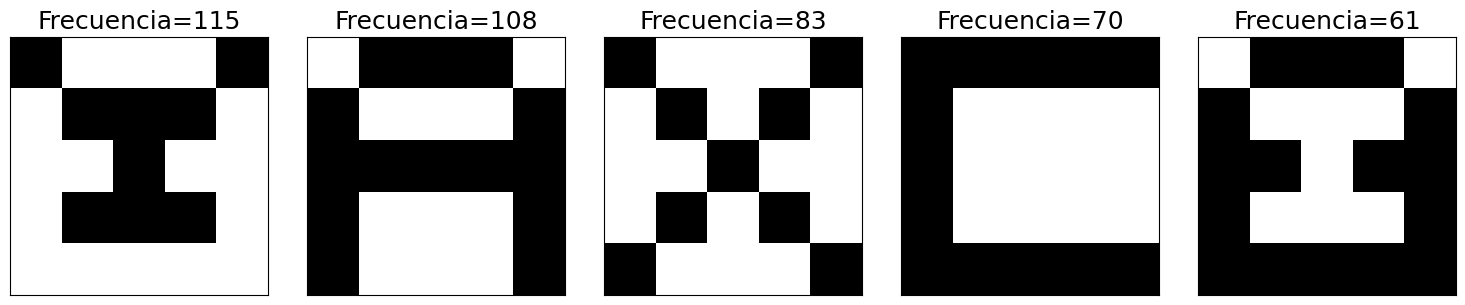

In [11]:
if len(df_spurious) > 0:
    n_show = min(5, len(df_spurious))
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))

    if n_show == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df_spurious.head(n_show).iterrows()):
        plot_pattern(row["state"], title=f"Frecuencia={row['count']}", ax=ax)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "hopfield_estados_espurios.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No se han encontrado estados espurios en este experimento.")

## 9. Experimento 5: paisaje energético discreto y temperatura

In [12]:
def enumerate_energies(W):
    """Enumera todos los estados {-1,1}^N y sus energías. Solo viable para N pequeño."""
    n = W.shape[0]
    states = np.array(list(itertools.product([-1, 1], repeat=n)))
    energies = np.array([-0.5 * s @ W @ s for s in states])
    return states, energies


def boltzmann_probabilities(energies, temperature):
    beta = 1.0 / temperature
    weights = np.exp(-beta * energies)
    return weights / weights.sum()


# Usamos una red muy pequeña para poder enumerar todos los estados.
small_patterns = np.array([
    [ 1,  1, -1, -1,  1, -1],
    [ 1, -1,  1, -1,  1, -1]
])

small_net = HopfieldNetwork().fit(small_patterns)
states_small, energies_small = enumerate_energies(small_net.W)

temperatures = np.linspace(0.2, 5.0, 25)
rows = []

for T in temperatures:
    probs = boltzmann_probabilities(energies_small, T)
    mean_E = np.sum(probs * energies_small)
    entropy = -np.sum(probs * np.log(probs + 1e-12))

    rows.append({
        "temperature": T,
        "mean_energy": mean_E,
        "entropy": entropy,
        "max_probability": probs.max()
    })

df_boltzmann = pd.DataFrame(rows)
df_boltzmann.to_csv(TABLES_DIR / "boltzmann_temperatura.csv", index=False)
df_boltzmann.head()

,temperature,mean_energy,entropy,max_probability
0,0.2,-2.309994,1.538231,0.241344
1,0.4,-2.165249,2.009819,0.204006
2,0.6,-1.846183,2.646540,0.159674
3,0.8,-1.475042,3.181460,0.121408
4,1.0,-1.170745,3.522749,0.094405


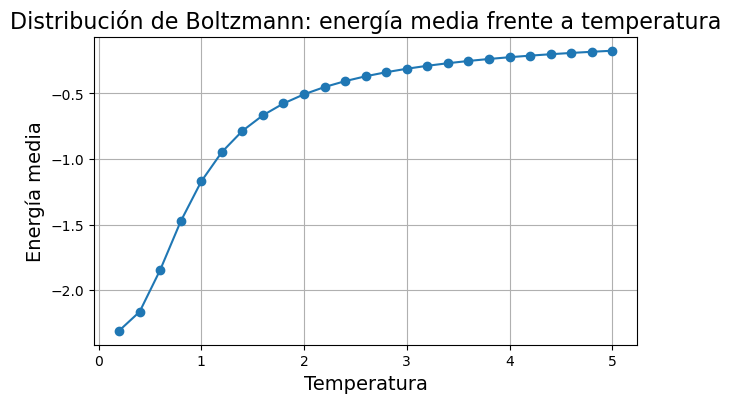

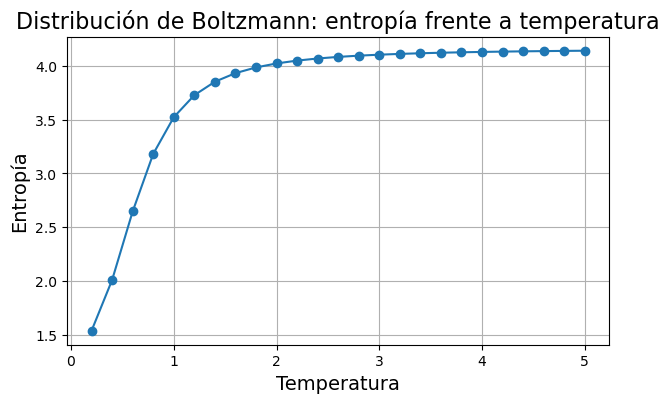

In [13]:
plt.figure()
plt.plot(df_boltzmann["temperature"], df_boltzmann["mean_energy"], marker="o")
plt.xlabel("Temperatura",fontsize=14)
plt.ylabel("Energía media",fontsize=14)
plt.title("Distribución de Boltzmann: energía media frente a temperatura",fontsize=16)
plt.savefig(FIGURES_DIR / "boltzmann_energia_temperatura.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_boltzmann["temperature"], df_boltzmann["entropy"], marker="o")
plt.xlabel("Temperatura",fontsize=14)
plt.ylabel("Entropía",fontsize=14)
plt.title("Distribución de Boltzmann: entropía frente a temperatura",fontsize=16)
plt.savefig(FIGURES_DIR / "boltzmann_entropia_temperatura.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. RBM sobre `digits`: carga, normalización y división train/test

In [14]:
digits = load_digits()
X = digits.data
y = digits.target

# Normalizamos a [0,1], adecuado para BernoulliRBM.
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X = (X > 0.5).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Rango de valores:", X_train.min(), X_train.max())

Train: (1347, 64)
Test: (450, 64)
Rango de valores: 0.0 1.0


## 11. Experimento 6: entrenamiento base de una RBM

In [15]:
rbm_base = BernoulliRBM(
    n_components=64,
    learning_rate=0.05,
    n_iter=30,
    batch_size=20,
    random_state=SEED,
    verbose=True
)

start = time.time()
rbm_base.fit(X_train)
train_time = time.time() - start

def reconstruct_rbm(model, X): #función de reconstrucción de imagenes
    H = model.transform(X)      #calcula a partir de la imagen X el valor de las variables ocultas, calcula P(h/v)
    V_recon_prob = 1 / (1 + np.exp(-(H @ model.components_ + model.intercept_visible_))) #reconstrucción de la capa visible a partir de H
    #es exactamente P(v/h)=sigma(W*h+b)
    return V_recon_prob


X_train_rec = reconstruct_rbm(rbm_base,X_train)
X_test_rec = reconstruct_rbm(rbm_base,X_test)

train_mse = mean_squared_error(X_train, X_train_rec) #Datos de entrenamiento MSE
test_mse = mean_squared_error(X_test, X_test_rec)    #Datos de prueba
train_bce = binary_cross_entropy(X_train, X_train_rec)
test_bce = binary_cross_entropy(X_test, X_test_rec)

print(f"Tiempo de entrenamiento: {train_time:.2f} s")
print(f"MSE train: {train_mse:.4f}")
print(f"MSE test:  {test_mse:.4f}")
print(f"BCE train: {train_bce:.4f}")
print(f"BCE test:  {test_bce:.4f}")

[BernoulliRBM] Iteration 1, pseudo-likelihood = -29.54, time = 0.01s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -28.43, time = 0.02s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -28.47, time = 0.02s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -28.26, time = 0.02s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -27.85, time = 0.02s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -27.38, time = 0.02s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -25.00, time = 0.02s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -23.92, time = 0.02s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -23.30, time = 0.02s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -22.15, time = 0.02s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -21.85, time = 0.02s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -21.60, time = 0.02s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -21.12, time = 0.02s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -21.43, time = 0.02s
[BernoulliRBM] Iteration 15, 

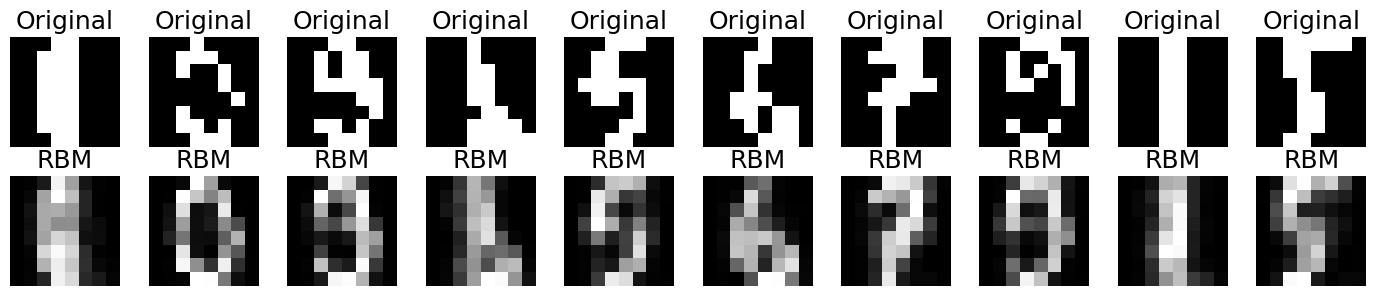

In [16]:
n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(14, 3))

for i in range(n_show):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[0, i].set_title("Original",fontsize=18)
    axes[0, i].axis("off")

    axes[1, i].imshow(X_test_rec[i].reshape(8, 8), cmap="gray")
    axes[1, i].set_title("RBM",fontsize=18)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rbm_reconstrucciones_base.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Experimento 7: comparación de configuraciones de la RBM

In [17]:
def evaluate_rbm_grid(
    X_train,
    X_test,
    hidden_list=(16, 32, 64, 128),
    iter_list=(10, 20, 30, 50),
    learning_rate=0.05,
    batch_size=20,
    seed=42
):
    rows = []

    for n_hidden in hidden_list:
        for n_iter in iter_list:
            rbm = BernoulliRBM(
                n_components=n_hidden,
                learning_rate=learning_rate,
                n_iter=n_iter,
                batch_size=batch_size,
                random_state=seed,
                verbose=False
            )

            start = time.time()
            rbm.fit(X_train)
            elapsed = time.time() - start

            X_train_rec = reconstruct_rbm(rbm,X_train)
            X_test_rec = reconstruct_rbm(rbm,X_test)

            rows.append({
                "n_hidden": n_hidden,
                "n_iter": n_iter,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "train_mse": mean_squared_error(X_train, X_train_rec),
                "test_mse": mean_squared_error(X_test, X_test_rec),
                "train_bce": binary_cross_entropy(X_train, X_train_rec),
                "test_bce": binary_cross_entropy(X_test, X_test_rec),
                "generalization_gap_mse": mean_squared_error(X_test, X_test_rec) - mean_squared_error(X_train, X_train_rec),
                "training_time_seconds": elapsed
            })

    return pd.DataFrame(rows)


df_rbm_grid = evaluate_rbm_grid(
    X_train,
    X_test,
    hidden_list=[16, 32, 64, 128],
    iter_list=[10, 20, 30, 50],
    learning_rate=0.05,
    batch_size=20,
    seed=SEED
)

df_rbm_grid.to_csv(TABLES_DIR / "rbm_grid_resultados.csv", index=False)
df_rbm_grid

,n_hidden,n_iter,learning_rate,batch_size,train_mse,test_mse,train_bce,test_bce,generalization_gap_mse,training_time_seconds
0,16,10,0.05,20,0.117524,0.117952,0.358459,0.360026,0.000428,0.081290
1,16,20,0.05,20,0.087505,0.088165,0.279770,0.282115,0.000661,0.174838
2,16,30,0.05,20,0.077430,0.078632,0.250525,0.254373,0.001203,0.260805
3,16,50,0.05,20,0.067636,0.068841,0.222457,0.226446,0.001205,0.423214
4,32,10,0.05,20,0.104624,0.104288,0.326219,0.326118,-0.000336,0.102558
5,32,20,0.05,20,0.081729,0.082455,0.262331,0.264758,0.000726,0.216043
6,32,30,0.05,20,0.070390,0.071358,0.231059,0.233940,0.000969,0.387611
7,32,50,0.05,20,0.060991,0.061899,0.202367,0.205041,0.000908,0.584544
8,64,10,0.05,20,0.104025,0.103616,0.323411,0.322803,-0.000409,0.160121
9,64,20,0.05,20,0.081441,0.081886,0.261565,0.263362,0.000445,0.297008


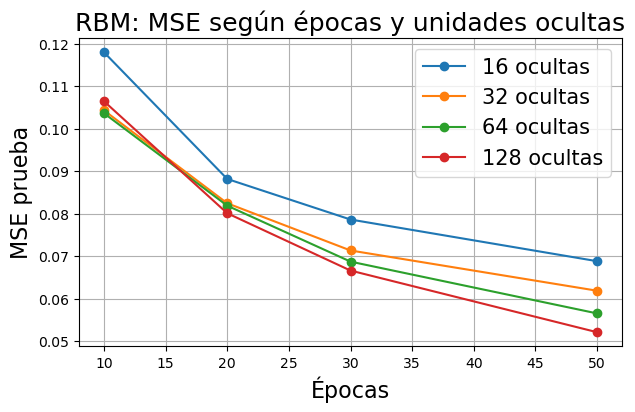

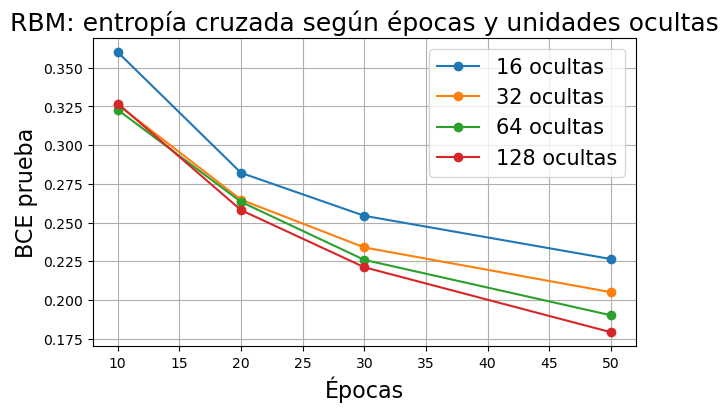

In [18]:
plt.figure()
for n_hidden in sorted(df_rbm_grid["n_hidden"].unique()):
    subset = df_rbm_grid[df_rbm_grid["n_hidden"] == n_hidden]
    plt.plot(subset["n_iter"], subset["test_mse"], marker="o", label=f"{n_hidden} ocultas")

plt.xlabel("Épocas",fontsize=16)
plt.ylabel("MSE prueba",fontsize=16)
plt.title("RBM: MSE según épocas y unidades ocultas",fontsize=18)
plt.legend(fontsize=15)
plt.savefig(FIGURES_DIR / "rbm_mse_grid.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
for n_hidden in sorted(df_rbm_grid["n_hidden"].unique()):
    subset = df_rbm_grid[df_rbm_grid["n_hidden"] == n_hidden]
    plt.plot(subset["n_iter"], subset["test_bce"], marker="o", label=f"{n_hidden} ocultas")

plt.xlabel("Épocas",fontsize=16)
plt.ylabel("BCE prueba",fontsize=16)
plt.title("RBM: entropía cruzada según épocas y unidades ocultas",fontsize=18)
plt.legend(fontsize=15)
plt.savefig(FIGURES_DIR / "rbm_bce_grid.png", dpi=200, bbox_inches="tight")
plt.show()

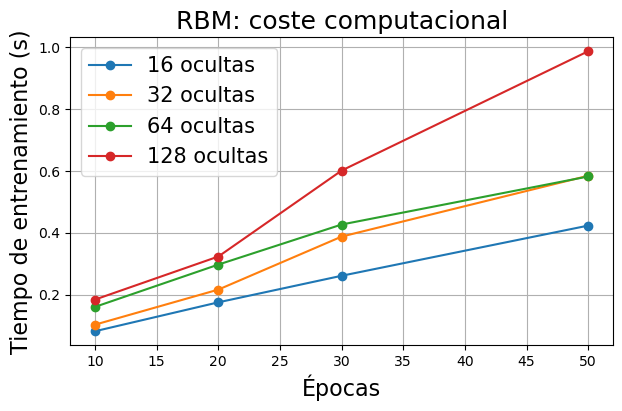

In [19]:
plt.figure()
for n_hidden in sorted(df_rbm_grid["n_hidden"].unique()):
    subset = df_rbm_grid[df_rbm_grid["n_hidden"] == n_hidden]
    plt.plot(subset["n_iter"], subset["training_time_seconds"], marker="o", label=f"{n_hidden} ocultas")

plt.xlabel("Épocas",fontsize=16)
plt.ylabel("Tiempo de entrenamiento (s)",fontsize=16)
plt.title("RBM: coste computacional",fontsize=18)
plt.legend(fontsize=15)
plt.savefig(FIGURES_DIR / "rbm_tiempo_grid.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Experimento 8: comparación train/test y posible sobreajuste

In [20]:
best_row = df_rbm_grid.sort_values("test_mse").iloc[0]
best_row

n_hidden                  128.000000
n_iter                     50.000000
learning_rate               0.050000
batch_size                 20.000000
train_mse                   0.051237
test_mse                    0.052148
train_bce                   0.176470
test_bce                    0.179204
generalization_gap_mse      0.000911
training_time_seconds       0.987595
Name: 15, dtype: float64

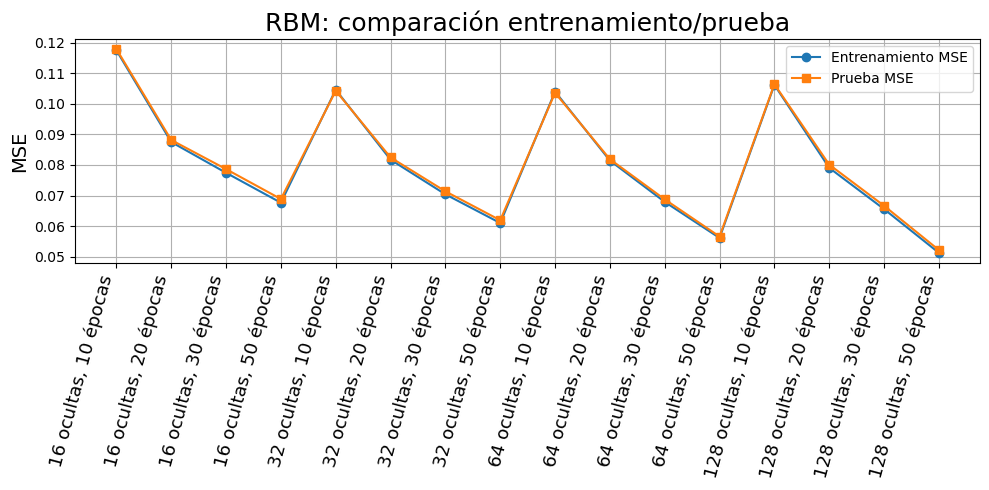

In [21]:
df_train_test = df_rbm_grid.copy()
df_train_test["config"] = (
    df_train_test["n_hidden"].astype(str) + " ocultas, " +
    df_train_test["n_iter"].astype(str) + " épocas"
)

plt.figure(figsize=(10, 5))
x = np.arange(len(df_train_test))
plt.plot(x, df_train_test["train_mse"], marker="o", label="Entrenamiento MSE")
plt.plot(x, df_train_test["test_mse"], marker="s", label="Prueba MSE")
plt.xticks(x, df_train_test["config"], rotation=75, ha="right",fontsize=13)
plt.ylabel("MSE",fontsize=14)
plt.title("RBM: comparación entrenamiento/prueba",fontsize=18)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rbm_train_test_mse.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Experimento 9: visualización e interpretación de filtros de la RBM

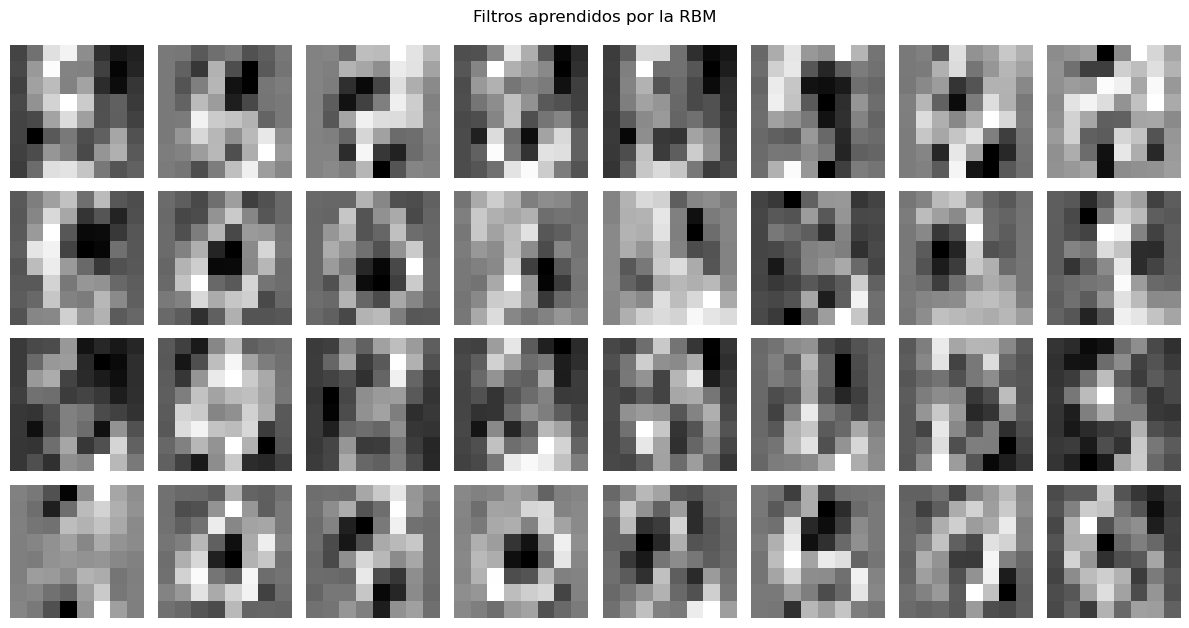

In [22]:
# Entrenamos una RBM final con la mejor configuración según MSE de test.
rbm_best = BernoulliRBM(
    n_components=int(best_row["n_hidden"]),
    learning_rate=float(best_row["learning_rate"]),
    n_iter=int(best_row["n_iter"]),
    batch_size=int(best_row["batch_size"]),
    random_state=SEED,
    verbose=False
)
rbm_best.fit(X_train)

n_filters = min(32, rbm_best.components_.shape[0])
n_cols = 8
n_rows = int(np.ceil(n_filters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 1.6 * n_rows))
axes = np.ravel(axes)

for ax, comp in zip(axes, rbm_best.components_[:n_filters]):
    ax.imshow(comp.reshape(8, 8), cmap="gray")
    ax.axis("off")

for ax in axes[n_filters:]:
    ax.axis("off")

plt.suptitle("Filtros aprendidos por la RBM")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rbm_filtros.png", dpi=200, bbox_inches="tight")
plt.show()

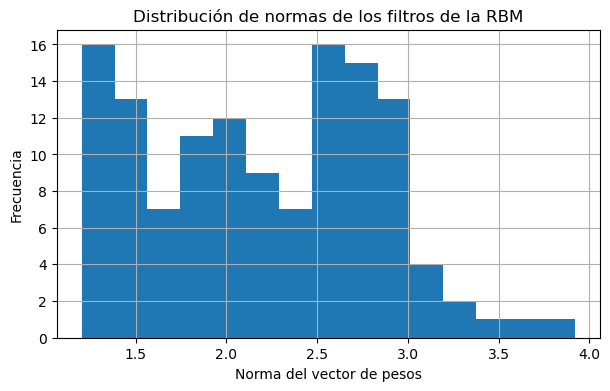

In [23]:
weight_norms = np.linalg.norm(rbm_best.components_, axis=1)

plt.figure()
plt.hist(weight_norms, bins=15)
plt.xlabel("Norma del vector de pesos")
plt.ylabel("Frecuencia")
plt.title("Distribución de normas de los filtros de la RBM")
plt.savefig(FIGURES_DIR / "rbm_normas_filtros.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "filter_index": np.arange(len(weight_norms)),
    "weight_norm": weight_norms
}).to_csv(TABLES_DIR / "rbm_normas_filtros.csv", index=False)

## 15. Tablas resumen para incorporar a LaTeX

In [24]:
# Tabla compacta de Hopfield frente al ruido.
tabla_hop_ruido = df_hop_noise.copy()
tabla_hop_ruido["noise_level"] = tabla_hop_ruido["noise_level"].round(2)
tabla_hop_ruido["recovery_rate"] = tabla_hop_ruido["recovery_rate"].round(3)
tabla_hop_ruido["mean_overlap"] = tabla_hop_ruido["mean_overlap"].round(3)
tabla_hop_ruido["spurious_rate"] = tabla_hop_ruido["spurious_rate"].round(3)

tabla_hop_ruido.to_latex(
    TABLES_DIR / "tabla_hopfield_ruido.tex",
    index=False,
    escape=False,
    caption="Evaluación de la recuperación en la red de Hopfield para distintos niveles de ruido.",
    label="tab:hopfield-ruido"
)

# Tabla compacta de capacidad.
tabla_hop_capacity = df_hop_capacity[[
    "n_patterns", "alpha", "recovery_rate", "mean_overlap", "spurious_rate"
]].copy()
tabla_hop_capacity = tabla_hop_capacity.round(3)

tabla_hop_capacity.to_latex(
    TABLES_DIR / "tabla_hopfield_capacidad.tex",
    index=False,
    escape=False,
    caption="Evaluación de la capacidad de almacenamiento de la red de Hopfield.",
    label="tab:hopfield-capacidad"
)

# Tabla compacta de RBM.
tabla_rbm = df_rbm_grid[[
    "n_hidden", "n_iter", "train_mse", "test_mse", "train_bce", "test_bce", "training_time_seconds"
]].copy()
tabla_rbm = tabla_rbm.round(4)

tabla_rbm.to_latex(
    TABLES_DIR / "tabla_rbm_configuraciones.tex",
    index=False,
    escape=False,
    caption="Comparación de configuraciones de la RBM sobre el dataset digits.",
    label="tab:rbm-configuraciones"
)

print("Tablas LaTeX guardadas en:", TABLES_DIR.resolve())

Tablas LaTeX guardadas en: /Users/noeliarosales/TFG mates/resultados_capitulo_5/tablas


## 16. Conclusión del notebook

Este notebook proporciona el soporte computacional para redactar un Capítulo 5 con estructura experimental sólida. La clave no es solo presentar resultados, sino interpretarlos desde la triple perspectiva del TFG:

1. **Matemática**: métricas, convergencia, capacidad, mínimos locales.
2. **Física**: energía, temperatura, entropía, distribución de Boltzmann.
3. **Computacional**: implementación, coste, reproducibilidad, visualización y análisis empírico.